In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
np.random.seed(37)

In [22]:
my_vec1=np.array([0,0,0])
cov_mat1=np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample=np.random.multivariate_normal(my_vec1,cov_mat1,40)

In [23]:
df=pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target']=1

In [24]:
my_vec2=np.array([1,1,1])
cov_mat2=np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample=np.random.multivariate_normal(my_vec2,cov_mat2,40)

In [25]:
df1=pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df1['target']=0

In [27]:
df=pd.concat([df,df1],ignore_index=True)
df=df.sample(80)

In [28]:
df.head()

,feature1,feature2,feature3,target
55,2.121662,1.629127,0.528599,0
39,0.299598,1.798044,-0.904326,1
10,-0.009668,-0.138041,0.444164,1
3,-0.827579,0.534657,1.228386,1
23,0.568910,0.130055,-1.033743,1


In [30]:
import plotly.express as px
fig=px.scatter_3d(df,x='feature1',y='feature2',z='feature3',color='target')

fig.update_traces(marker=dict(size=12,line=dict(width=2,color='DarkSlateGrey')))

fig.show()

In [34]:
#Step-1 Apply Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df.iloc[:,0:3]=scaler.fit_transform(df.iloc[:,0:3])

In [35]:
#Step-2 Find Covv matrix
covarriance_matrix=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print("Covarriance Matrix : ",covarriance_matrix)

Covarriance Matrix :  [[ 1.01265823  0.12824734 -0.10262797]
 [ 0.12824734  1.01265823  0.18262786]
 [-0.10262797  0.18262786  1.01265823]]


In [37]:
#Step-3 Find Eigen values and vectors
eigen_values,eigen_vectors=np.linalg.eig(covarriance_matrix)


In [38]:
eigen_values

array([0.73410595, 1.10568193, 1.1981868 ])

In [39]:
eigen_vectors

array([[-0.50649976,  0.8476922 ,  0.15772106],
       [ 0.62360197,  0.23381255,  0.74595729],
       [-0.59546501, -0.47618235,  0.64704852]])

Populating the interactive namespace from numpy and matplotlib


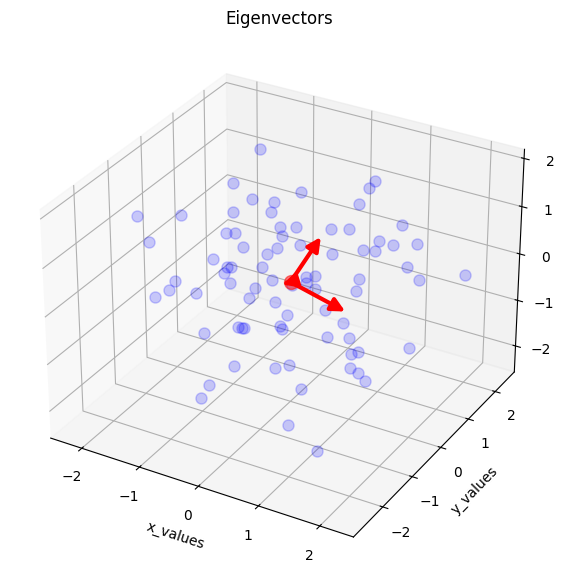

In [44]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs



    def do_3d_projection(self, renderer=None):
      xs3d, ys3d, zs3d = self._verts3d
      xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
      self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
      return np.min(zs)
    def draw(self, renderer):
      xs3d, ys3d, zs3d = self._verts3d
      xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
      self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
      super().draw(renderer)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
    a = Arrow3D([df['feature1'].mean(), v[0]], [df['feature2'].mean(), v[1]], [df['feature3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()


In [45]:
pc=eigen_vectors[0:2]
pc

array([[-0.50649976,  0.8476922 ,  0.15772106],
       [ 0.62360197,  0.23381255,  0.74595729]])

In [46]:
new_df=np.dot(df.iloc[:,0:3],pc.T)

new_df=pd.DataFrame(new_df,columns=['PC1','PC2'])
new_df['target']=df['target']
new_df.head()

,PC1,PC2,target
0,0.175176,1.230694,1
1,0.950240,-0.773276,1
2,-0.381548,-0.463000,1
3,0.695056,-0.216311,1
4,-0.636677,-1.109139,1


In [47]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()